# AutoGuard AI — Sprint 2.1 Statistical Verification

This executed notebook presents the frozen, reproducible Sprint 2.1 results. The full computation is in `02_Data/generation/run_sprint2_analysis.py`; it maintains the Sprint 1 Train/Validation/Test isolation.


In [1]:
from pathlib import Path
import json, pandas as pd
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='01_Notebook' else Path.cwd().resolve()
metadata=json.loads((ROOT/'03_Model/model_v2_metadata.json').read_text())
print('Active model:',metadata['version'])


Active model: v3.2.0-sprint2


## 1. Frozen Sprint 1 methodology and corrected NN audit

Development uses Training Pool and Real Validation; Test is excluded from model selection, calibration and threshold selection. NN C contains executable PyTorch Dropout(0.30) layers. The strongest NN is selected programmatically from the Validation table.


In [2]:
comparison=pd.read_csv(ROOT/'02_Data/processed/sprint2_validation_comparison.csv')
comparison


,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,model,training_time_sec
0,0.814259,0.679577,0.770459,0.722170,0.887556,0.776034,0.122026,Logistic Regression,0.184796
1,0.807380,0.692615,0.692615,0.692615,0.871561,0.753739,0.132328,Neural Network B,3.191225
2,0.797999,0.735450,0.554890,0.632537,0.866382,0.744818,0.143325,Neural Network A,0.838727
3,0.773609,0.906433,0.309381,0.461310,0.862870,0.743845,0.193860,Neural Network C,6.088262
4,0.790494,0.655431,0.698603,0.676329,0.831674,0.648582,0.153738,Random Forest,1.178521
5,0.686679,0.000000,0.000000,0.000000,0.500000,0.313321,0.313321,Baseline,0.187789


## 2. Paired comparison and bootstrap uncertainty

All model comparisons use 5,000 paired bootstrap samples. Classification CIs use the same explicit threshold as their associated point estimates.


In [3]:
pd.read_csv(ROOT/'02_Data/processed/sprint2_pairwise_model_comparisons.csv'), pd.read_csv(ROOT/'02_Data/processed/sprint2_bootstrap_confidence_intervals.csv')


(                                comparison  delta_roc_auc  \
 0  Logistic Regression vs Neural Network B       0.015995   
 1     Logistic Regression vs Random Forest       0.055883   
 
                                           ci_95  two_sided_bootstrap_p  \
 0  [0.009079667041318837, 0.022996941010350082]                 0.0004   
 1    [0.04075675624916053, 0.07218095077524424]                 0.0004   
 
    bootstrap_iterations  
 0                  5000  
 1                  5000  ,
        dataset  threshold             metric    ci_low   ci_high
 0   validation        0.5            roc_auc  0.869680  0.903785
 1   validation        0.5           accuracy  0.794872  0.833021
 2   validation        0.5          precision  0.639860  0.717547
 3   validation        0.5             recall  0.733456  0.806523
 4   validation        0.5                 f1  0.690875  0.751148
 5   validation        0.5  average_precision  0.736032  0.813311
 6   validation        0.5        brier_s

## 3. ROC, Precision-Recall and calibration


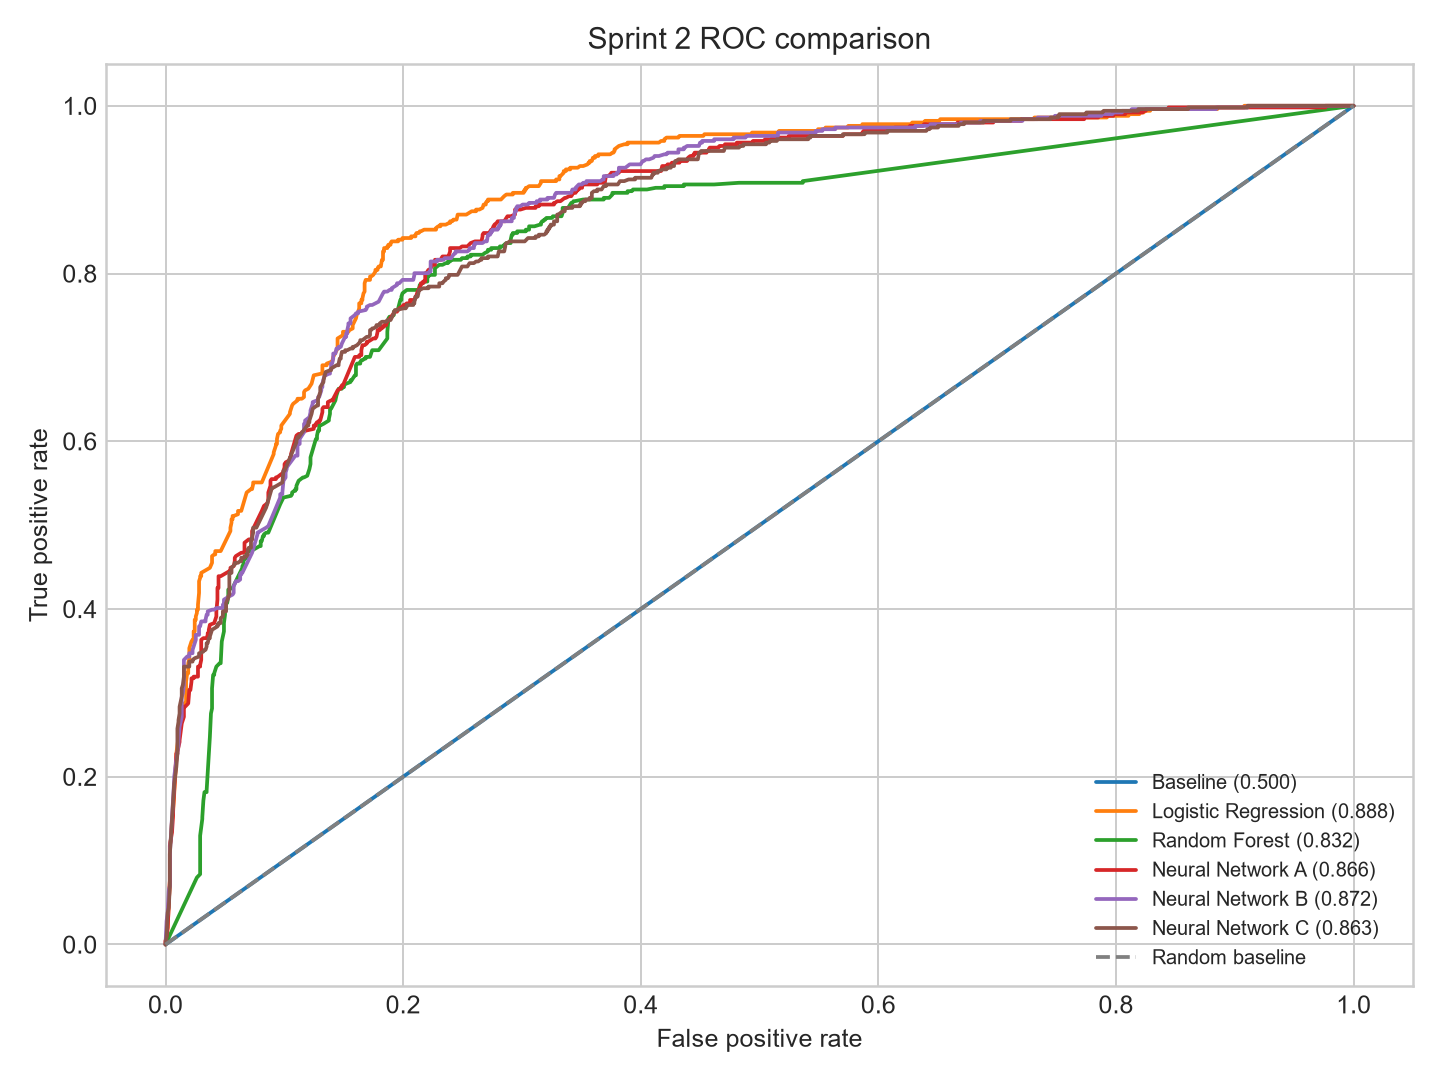

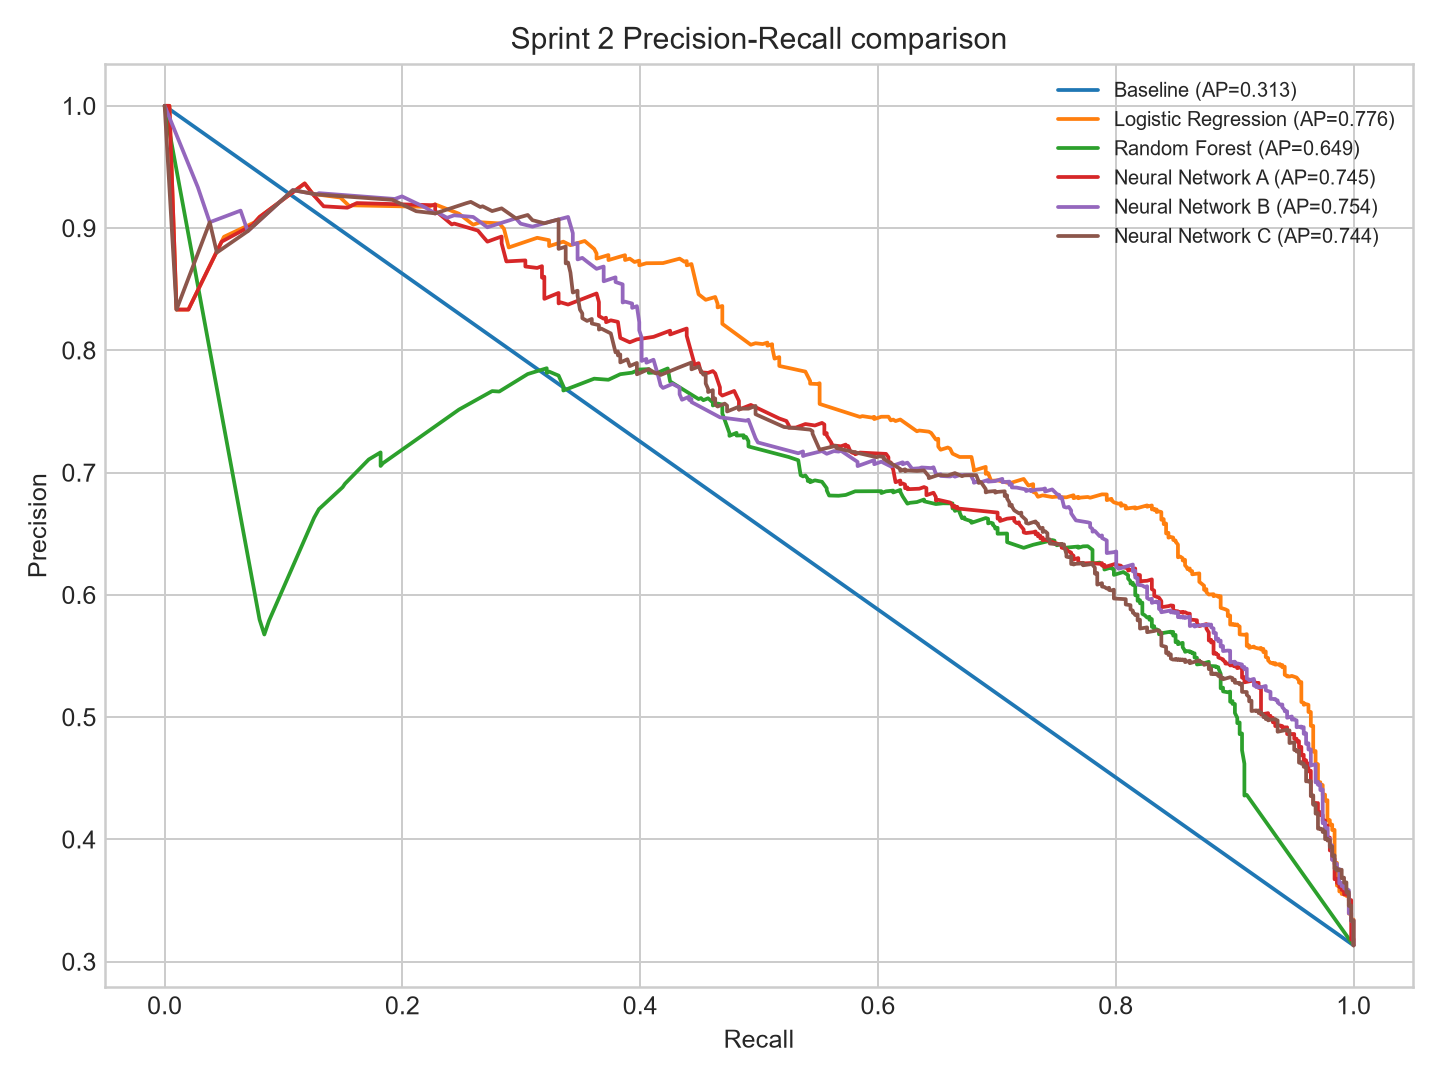

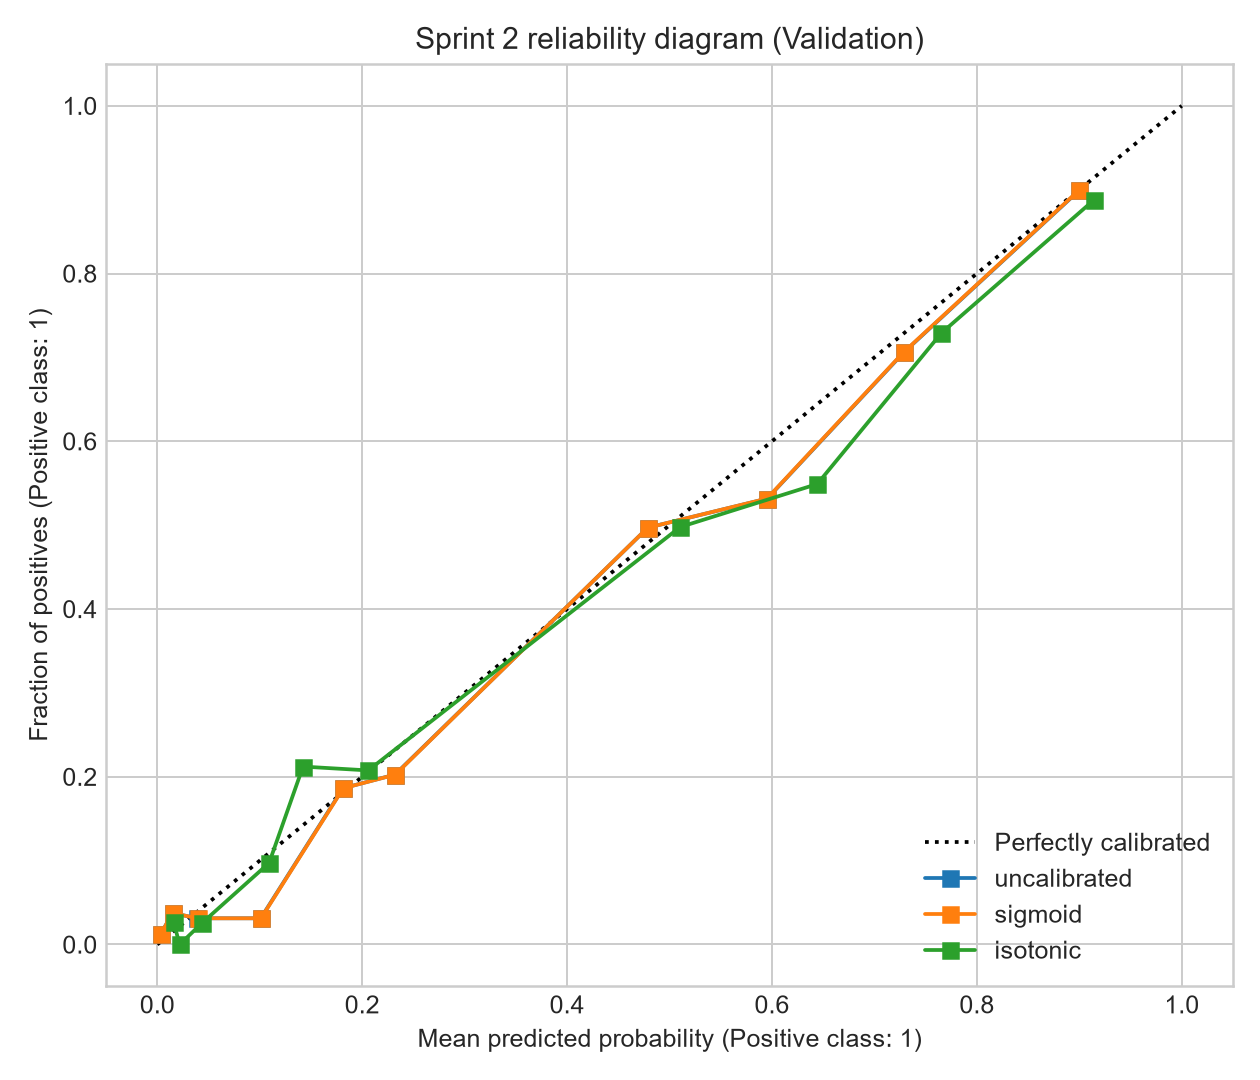

,method,brier_score,roc_auc,log_loss
0,uncalibrated,0.122026,0.887556,0.385646
1,sigmoid,0.122028,0.887549,0.385633
2,isotonic,0.122611,0.887235,0.385380


In [4]:
from IPython.display import Image, display
display(Image(ROOT/'05_Report/figures/sprint2/sprint2_roc_comparison.png'))
display(Image(ROOT/'05_Report/figures/sprint2/sprint2_precision_recall.png'))
display(Image(ROOT/'05_Report/figures/sprint2/sprint2_calibration_curve.png'))
pd.read_csv(ROOT/'02_Data/processed/sprint2_calibration_comparison.csv')


## 4. Threshold, error, segments and importance

The selected statistical threshold maximizes Validation F1. It is not a business threshold.


{'default_threshold': 0.5, 'selected_statistical_threshold': 0.3, 'selection_rule': 'maximum Validation F1', 'validation_table_file': '02_Data/processed/sprint2_threshold_analysis.csv', 'final_test_default_threshold': {'accuracy': 0.8250874562718641, 'precision': 0.7033773861967695, 'recall': 0.7639553429027113, 'f1': 0.7324159021406728, 'roc_auc': 0.8903305637389756, 'average_precision': 0.7793332466882207, 'brier_score': 0.12002122435491808}, 'final_test_selected_threshold': {'accuracy': 0.8220889555222389, 'precision': 0.6785243741765481, 'recall': 0.8213716108452951, 'f1': 0.7431457431457431, 'roc_auc': 0.8903305637389756, 'average_precision': 0.7793332466882207, 'brier_score': 0.12002122435491808, 'confusion_matrix': [[1130, 244], [112, 515]], 'n_evaluated': 2001}}


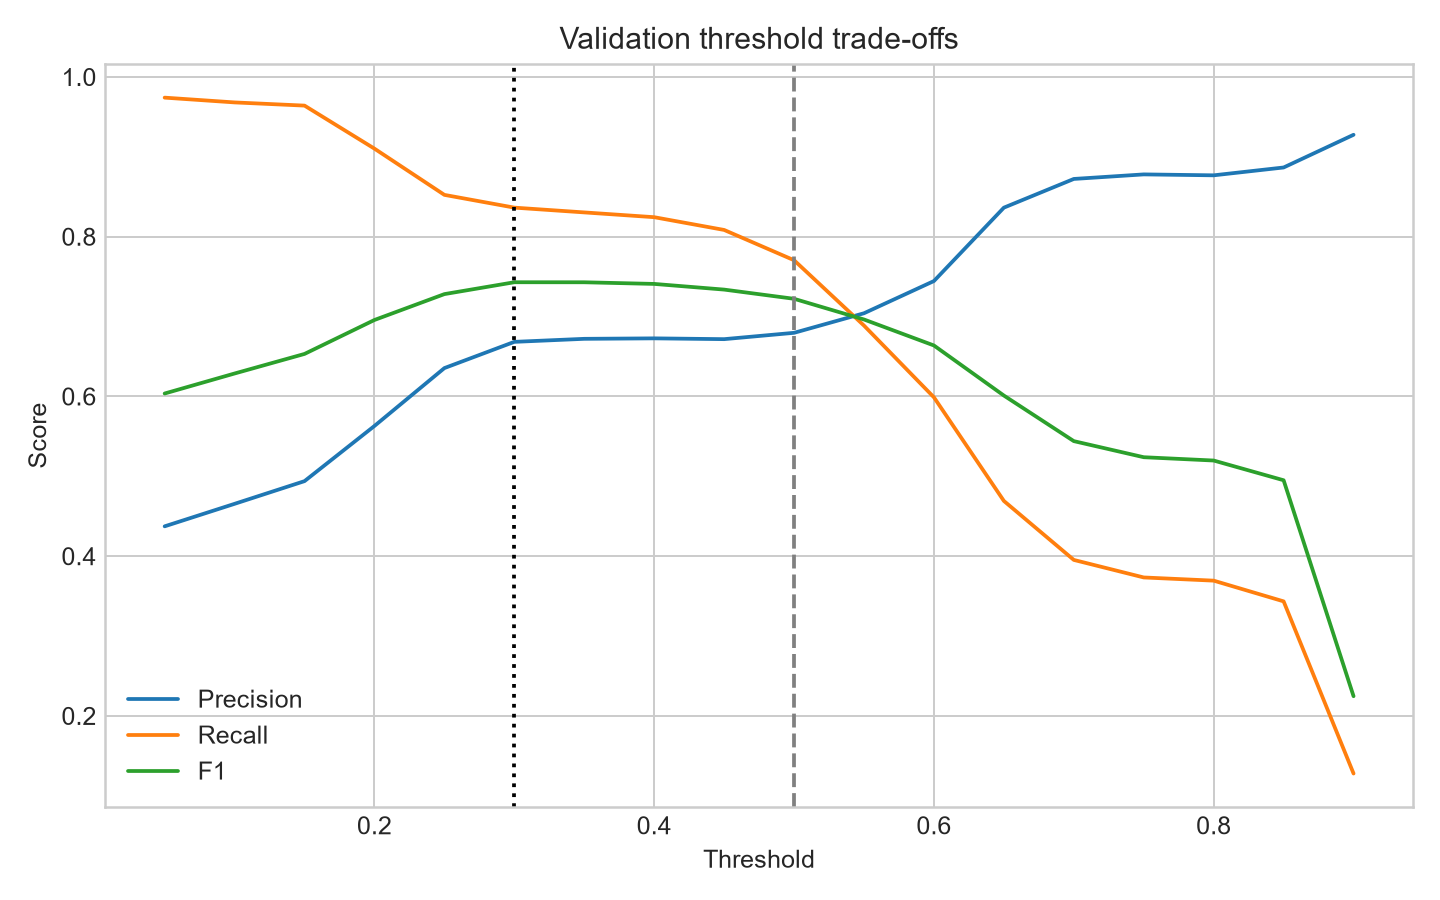

,feature,mean_importance,std_importance
0,DRIVING_EXPERIENCE,0.224515,0.009681
1,VEHICLE_OWNERSHIP,0.051141,0.004838
2,VEHICLE_YEAR,0.035469,0.004218
3,ANNUAL_MILEAGE,0.006658,0.002147
4,PAST_ACCIDENTS,0.004070,0.002057
5,SPEEDING_VIOLATIONS,0.003138,0.001644
6,AGE,0.001065,0.000791
7,DUIS,-0.000277,0.000692


In [5]:
print(metadata['threshold_analysis'])
display(Image(ROOT/'05_Report/figures/sprint2/sprint2_threshold_tradeoffs.png'))
pd.read_csv(ROOT/'02_Data/processed/sprint2_permutation_importance.csv')


## 5. Final independent Test results and artifact verification

The Test set was accessed only after model, calibration and threshold decisions were frozen.


In [6]:
print('FINAL TEST RESULTS:',metadata['final_test_results'])
print('Final Test CIs:',metadata['statistical_validation']['final_test_confidence_intervals'])
print('SHA-256:',metadata['artifact_sha256'])


FINAL TEST RESULTS: {'accuracy': 0.8220889555222389, 'precision': 0.6785243741765481, 'recall': 0.8213716108452951, 'f1': 0.7431457431457431, 'roc_auc': 0.8903305637389756, 'average_precision': 0.7793332466882207, 'brier_score': 0.12002122435491808, 'confusion_matrix': [[1130, 244], [112, 515]], 'n_evaluated': 2001}
Final Test CIs: {'roc_auc': [0.8750292481220165, 0.9054862407335572], 'accuracy': [0.8055972013993004, 0.8385807096451774], 'precision': [0.6455521683642336, 0.7108284091781136], 'recall': [0.7913174465533169, 0.8517299487056891], 'f1': [0.7174887892376681, 0.7679696189007802], 'average_precision': [0.7436543516813515, 0.8143304551050005], 'brier_score': [0.11101354671249411, 0.1290414871654361]}
SHA-256: 71d1474c36c4719a950e62659c34d28701c6ec66e072e01b18d6f67344932daf
